# CloudLedger — Variance Deep Dive: Drift Analysis & Terraform Import Priorities

This notebook investigates resources flagged as **drift** (not tracked by Terraform) and produces a prioritized list for Terraform import based on cost impact and risk scoring.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load billing data
data_dir = os.path.join('..', 'data', 'samples')
month1 = pd.read_csv(os.path.join(data_dir, 'month1.csv'))
month2 = pd.read_csv(os.path.join(data_dir, 'month2.csv'))

# Load terraform state to identify managed vs unmanaged
with open(os.path.join(data_dir, 'terraform.tfstate')) as f:
    tf_state = json.load(f)

# Extract all managed resource ARNs
managed_arns = set()
for resource in tf_state.get('resources', []):
    for instance in resource.get('instances', []):
        attrs = instance.get('attributes', {})
        if attrs.get('arn'): managed_arns.add(attrs['arn'])
        if attrs.get('id'): managed_arns.add(attrs['id'])

# Flag drift resources in month2
def is_managed(rid):
    return any(rid in arn or arn in rid for arn in managed_arns)

month2['in_terraform'] = month2['ResourceId'].apply(is_managed)
month2['parsed_tags'] = month2['Tags'].apply(lambda t: json.loads(t) if isinstance(t, str) else {})
month2['team'] = month2['parsed_tags'].apply(lambda t: t.get('team', 'Unknown'))

drift_df = month2[~month2['in_terraform']].copy()
managed_df = month2[month2['in_terraform']].copy()

print(f'Terraform-managed identifiers: {len(managed_arns)}')
print(f'Month 2 resources: {len(month2)}')
print(f'Drift resources: {len(drift_df)} (${drift_df["BilledCost"].sum():,.0f})')
print(f'Managed resources: {len(managed_df)} (${managed_df["BilledCost"].sum():,.0f})')

Terraform-managed identifiers: 70
Month 2 resources: 50
Drift resources: 15 ($28,266)
Managed resources: 35 ($83,734)


## Drift by Service

/var/folders/d_/hr38rp8j2zddtshj5z9s2pcc0000gn/T/ipykernel_78095/3716481824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drift_by_service, x='total_cost', y='ServiceName', palette='Reds_r', ax=ax1)
/var/folders/d_/hr38rp8j2zddtshj5z9s2pcc0000gn/T/ipykernel_78095/3716481824.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drift_by_service, x='count', y='ServiceName', palette='Oranges_r', ax=ax2)


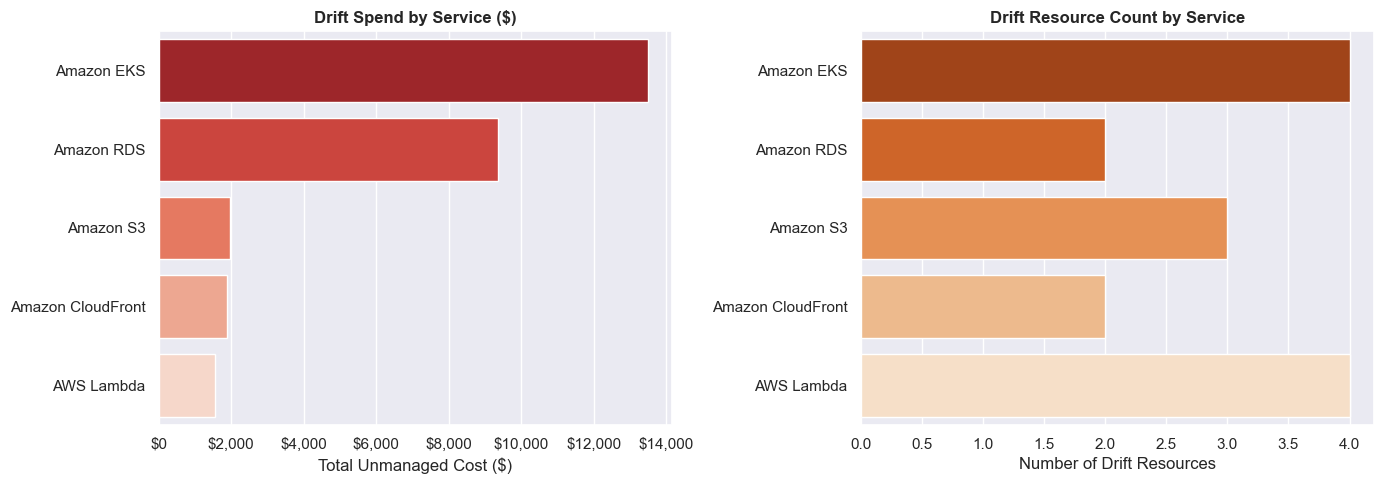

      ServiceName  count  total_cost  avg_cost
       Amazon EKS      4    13492.32 3373.0800
       Amazon RDS      2     9367.77 4683.8850
        Amazon S3      3     1960.32  653.4400
Amazon CloudFront      2     1894.51  947.2550
       AWS Lambda      4     1550.97  387.7425


In [2]:
# Seaborn: drift spend breakdown by service
drift_by_service = drift_df.groupby('ServiceName').agg(
    count=('ResourceId', 'count'),
    total_cost=('BilledCost', 'sum'),
    avg_cost=('BilledCost', 'mean'),
).sort_values('total_cost', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=drift_by_service, x='total_cost', y='ServiceName', palette='Reds_r', ax=ax1)
ax1.set_title('Drift Spend by Service ($)', fontweight='bold')
ax1.set_xlabel('Total Unmanaged Cost ($)')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.barplot(data=drift_by_service, x='count', y='ServiceName', palette='Oranges_r', ax=ax2)
ax2.set_title('Drift Resource Count by Service', fontweight='bold')
ax2.set_xlabel('Number of Drift Resources')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print(drift_by_service.to_string(index=False))

Compute-intensive services (EC2, EKS) dominate drift spend, which is concerning because these resources have the highest cost and growth potential without governance controls.

## Drift Cost Growth Analysis

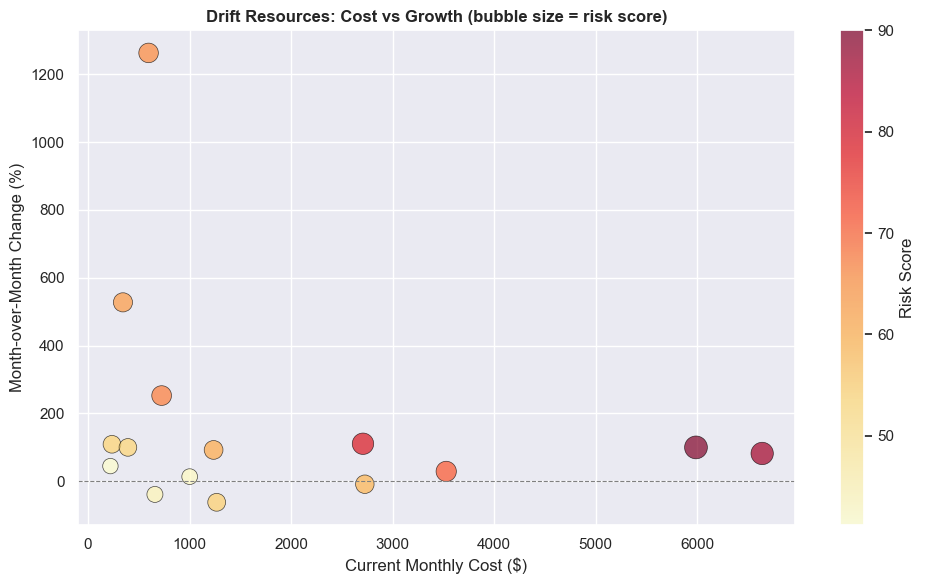

In [3]:
# Compare drift resources across months to measure growth
m1_costs = month1.set_index('ResourceId')['BilledCost'].to_dict()

drift_df = drift_df.copy()
drift_df['prior_cost'] = drift_df['ResourceId'].map(m1_costs).fillna(0)
drift_df['delta'] = drift_df['BilledCost'] - drift_df['prior_cost']
drift_df['pct_change'] = np.where(
    drift_df['prior_cost'] > 0,
    drift_df['delta'] / drift_df['prior_cost'] * 100,
    100  # New drift resources get 100% "growth"
)

# Risk scoring: combine cost magnitude with growth rate and ownership gap
drift_df['risk_score'] = (
    np.clip(drift_df['BilledCost'] / 100, 0, 40) +
    np.clip(np.abs(drift_df['pct_change']) / 5, 0, 30) +
    30  # No terraform = automatic 30 risk points
).clip(0, 100).round(1)

# Matplotlib scatter: cost vs growth
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    drift_df['BilledCost'],
    drift_df['pct_change'],
    s=drift_df['risk_score'] * 3,
    c=drift_df['risk_score'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5,
)
ax.set_xlabel('Current Monthly Cost ($)')
ax.set_ylabel('Month-over-Month Change (%)')
ax.set_title('Drift Resources: Cost vs Growth (bubble size = risk score)', fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.colorbar(scatter, label='Risk Score')
plt.tight_layout()
plt.show()

In [4]:
# Interactive Plotly scatter for drill-down
fig = px.scatter(
    drift_df,
    x='BilledCost', y='pct_change',
    size='risk_score', color='ServiceName',
    hover_name='ResourceName',
    hover_data=['team', 'risk_score', 'delta'],
    title='Drift Resources — Interactive Risk Map (hover for details)',
    labels={'BilledCost': 'Current Cost ($)', 'pct_change': 'MoM Change (%)', 'ServiceName': 'Service'},
    height=500,
)
fig.update_layout(xaxis_tickformat='$,.0f')
fig.show()

Resources in the upper-right quadrant (high cost + high growth) should be the immediate priority for Terraform import or termination review.

## Terraform Import Priority List (Ranked by Cost)

In [5]:
# Priority list ranked by cost (highest cost = most urgent to import)
priority = drift_df[['ResourceId', 'ResourceName', 'ServiceName', 'team',
                     'BilledCost', 'delta', 'pct_change', 'risk_score']].copy()
priority = priority.sort_values('BilledCost', ascending=False).reset_index(drop=True)
priority.index += 1
priority.index.name = 'Priority'

# Terraform resource type mapping
tf_type_map = {
    'Amazon EC2': 'aws_instance',
    'Amazon RDS': 'aws_db_instance',
    'Amazon S3': 'aws_s3_bucket',
    'AWS Lambda': 'aws_lambda_function',
    'Amazon CloudFront': 'aws_cloudfront_distribution',
    'Amazon EKS': 'aws_eks_cluster',
}
priority['tf_type'] = priority['ServiceName'].map(tf_type_map)
priority['import_cmd'] = priority.apply(
    lambda r: f"terraform import {r['tf_type']}.{r['ResourceName']} {r['ResourceId']}",
    axis=1
)

print('=' * 60)
print('TERRAFORM IMPORT PRIORITY LIST')
print('=' * 60)
print(f'Total unmanaged spend: ${priority["BilledCost"].sum():,.0f}/month')
print(f'Resources to import: {len(priority)}')
print()
print(priority[['ResourceName', 'ServiceName', 'team', 'BilledCost', 'risk_score']].head(15).to_string())
print()
print('--- Top 5 Import Commands ---')
for _, row in priority.head(5).iterrows():
    print(f"  {row['import_cmd']}")

TERRAFORM IMPORT PRIORITY LIST
Total unmanaged spend: $28,266/month
Resources to import: 15

                      ResourceName        ServiceName      team  BilledCost  risk_score
Priority                                                                               
1                     prod-db-3964         Amazon RDS  data-eng     6641.22        86.4
2                         1b721076         Amazon EKS  frontend     5989.07        90.0
3                         c3712da8         Amazon EKS   backend     3528.24        71.1
4                     prod-db-e72e         Amazon RDS  platform     2726.55        59.0
5                         1b4d419b         Amazon EKS   backend     2708.15        79.2
6                         a0fa5f6b         Amazon EKS   backend     1266.86        55.0
7                         32684b27  Amazon CloudFront   backend     1236.31        60.9
8          cloudledger-backup-64f7          Amazon S3    ml-ops     1000.81        42.8
9         cloudledger-stagi

## Business Recommendations

1. **Import the top 5 drift resources immediately** — they represent the bulk of unmanaged spend and pose the highest compliance risk. Use the generated `terraform import` commands above.

2. **Set a governance rule**: any resource costing >$500/month MUST be in Terraform within 7 days of creation. Enforce via a weekly CloudLedger drift detection cron job.

3. **Investigate S3 buckets** without lifecycle policies — they grow silently and can become the largest surprise cost category over time.

4. **Assign CloudTrail ownership** to all drift resources. Many have generic team tags but no specific owner, making accountability difficult.

5. **Consider Karpenter for EKS** drift resources — if clusters are running without Terraform, they likely also lack autoscaling optimization, leading to chronic overprovisioning.